In [126]:
import warnings
warnings.filterwarnings('ignore')

import os
import pickle

import numpy as np
import pandas as pd

from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

from pandas.tseries.offsets import MonthEnd, MonthBegin
from maricovault.MaricoDB import MaricoSnowflake

from joblib import Parallel, delayed

In [127]:
def get_dbconnection(db_name): 

    KEY_VAULT_NAME = "prod-pwd"
    if db_name == 'PROD':
        db_name = 'prod'
    else:
        db_name = 'dev'

    msf = MaricoSnowflake(KEY_VAULT_NAME)
    msf.get_db_credentials(db_name=db_name)
    msf.connect()
    dbconnection = msf.get_connection()
    
    return dbconnection

In [128]:
dev_conn = get_dbconnection('DEV')
prod_conn = get_dbconnection('PROD')


Credentials retrieved successfully for dev db.

Credentials retrieved successfully for prod db.


### Helper functions

In [129]:
realignment_df = pd.read_sql(
    """select * from trn_mil_asm_psku_realignment""",
    dev_conn
)
realignment_df.columns = realignment_df.columns.str.lower()

realignment_df = realignment_df[
    realignment_df['channel'].isin(['QCOM', 'QCOM B2C', 'ALL'])]


def realign_pskus(data, column):
    realignment_data = realignment_df.copy()
    assert realignment_data['psku old'].dtype == 'int64'
    assert realignment_data['psku new'].dtype == 'int64'
    realignment_data = realignment_data[['psku old', 'psku new']].drop_duplicates()
    realignment_data = realignment_data.set_index('psku old').to_dict()['psku new']

    
    data[column] = data[column].astype(int)

    for old_psku, new_psku in realignment_data.items():
        data.loc[
            data[column] == old_psku, column
        ] = new_psku

    return data

In [130]:
from tqdm import tqdm

def impute_missing_dates(
        df,
        freq='M',
        key=['CHAIN', 'FACILITY_NAME', 'PARENT_MATERIAL_CODE'], 
        date_col='MONTH_DATE',
        max_date='2026-12-31'
    ):

    impute_df = df.copy()
    impute_df[date_col] = pd.to_datetime(impute_df[date_col])
    impute_df['key'] = impute_df[key].astype(str).agg('_'.join, axis=1)
    min_dates_df = impute_df.groupby(
        'key', as_index=False
    )[date_col].min()

    def impute_missing_dates_key(key, min_date, max_date):
        df_imputed = pd.DataFrame(
            pd.date_range(min_date, max_date, freq=freq),
            columns=[date_col]
        )
        df_imputed['key'] = key
        return df_imputed
    
    outputs = Parallel(n_jobs=-1)(
        delayed(impute_missing_dates_key)(row['key'], row[date_col], max_date)
        for idx, row in tqdm(min_dates_df.iterrows())
    )
    df_full = pd.concat(outputs)
    df_full.reset_index(drop=True, inplace=True)

    df_full = df_full.merge(
        impute_df, on=['key', date_col], how='left',
    )

    return df_full

In [131]:
non_rc_to_rc_mapping = {
    718948: 722208,
    718356: 721837,
    718455: 721963,
    718341: 721898,
    718342: 721836,
    719008: 721842,
    729186: 729165,
    718288: 721843,
    722301: 722302
}

rc_to_non_rc_mapping = {value: key for key, value in non_rc_to_rc_mapping.items()}

rc_skus = list(rc_to_non_rc_mapping.keys()) + [729280]
non_rc_skus = list(rc_to_non_rc_mapping.values())

In [132]:
def get_final_psku(x):
    if x['zone'] in ['North', 'East']:
        if (x['rc_psku'] == 1):
            return x['parent_material_code']
        else:
            return non_rc_to_rc_mapping[x['parent_material_code']]
    else:
        if (x['rc_psku'] == 0):
            return x['parent_material_code']
        else:
            return rc_to_non_rc_mapping[x['parent_material_code']]   
        
            
def zepto_saff_golf_fix(df):

    df = df.copy()

    zepto_gold_df = df[
        (df['chain'] == 'Zepto') &
        (df['material_group_code'] == 'SAFF GOLD')
    ]

    rest = df[
        ~((df['chain'] == 'Zepto') &
        (df['material_group_code'] == 'SAFF GOLD'))
    ]

    ########### Offtake City to New City ###########
    city_mappings_df = pd.read_excel(
        r'/data/aman_singh/mt_forecast/City Mappings QCOM.xlsb', 
        'Final'
    )

    city_mappings_df.rename(columns={'City': 'warehouse_city', 'Final City': 'final'}, inplace=True)

    city_mappings_df.columns = city_mappings_df.columns.str.lower()

    assert city_mappings_df.duplicated(subset=['platform_name', 'city']).sum() == 0

    city_mappings_df.rename(columns={'platform_name': 'chain'}, inplace=True)
    #####################################################################


    #### New City to Zone Mappings #######
    # region_mappings = pd.read_excel(
    #     r"C:\Users\aniket.patel\OneDrive - Marico Ltd\Zepto - SAFF GOLD - Region Mappings.xlsx"    
    # )
    # region_mappings.columns = region_mappings.columns.str.lower()
    data_region = {
        "city": [
            "Faridabad", "Ahmedabad", "Jaipur", "Patiala", "Pune",
            "Bangalore", "GURGAON", "Medak", "Chennai", "Lucknow",
            "Hyderabad", "Jhajjar", "Howrah", "Mumbai", "Bhiwandi"
        ],
        "State/Region": [
            "Haryana", "Gujarat", "Rajasthan", "Punjab", "Maharashtra",
            "Karnataka", "Haryana", "Telangana", "Tamil Nadu", "Uttar Pradesh",
            "Telangana", "Haryana", "West Bengal", "Maharashtra", "Maharashtra"
        ],
        "zone": [
            "North", "West", "North", "North", "West",
            "South", "North", "South", "South", "North",
            "South", "North", "East", "West", "West"
        ]
    }

    region_mappings = pd.DataFrame(data_region)
    #######################################


    ### FIX ####
    len_before_merge = len(zepto_gold_df)
    zepto_gold_df = zepto_gold_df.merge(
        city_mappings_df[['chain', 'city', 'final']],
        on=['chain', 'city'],
        how='left'
    )
    assert len_before_merge == len(zepto_gold_df)
    del len_before_merge

    zepto_gold_df = zepto_gold_df[zepto_gold_df['final'].notna()]

    len_before_merge = len(zepto_gold_df)
    zepto_gold_df = zepto_gold_df.merge(
        region_mappings[['city', 'zone']].rename(
            columns={'city': 'final'}
        ),
        how='left', 
        on=['final']
    )
    assert len_before_merge == len(zepto_gold_df)
    del len_before_merge


    zepto_gold_df['rc_psku'] = zepto_gold_df['parent_material_code'].map(
        lambda x: 1 if x in rc_skus else 0
    )

    zepto_gold_df['final_psku'] = zepto_gold_df.apply(lambda x: get_final_psku(x), axis=1)

    zepto_gold_df = zepto_gold_df.groupby(
        ['chain', 'city', 'final_psku', 'material_group_code', 
        'month_date'], as_index=False
    )['vol_in_roum'].sum()
    zepto_gold_df.rename(columns={'final_psku': 'parent_material_code'}, inplace=True)

    df = pd.concat([rest, zepto_gold_df], ignore_index=True)

    return df

### Primary Actuals + Sec Plan Data

In [133]:
plan_actuals_query = """
-- Primary base table
SELECT 
    CASE
        WHEN MCM.chain = 'Kiranakart Technologies' THEN 'Zepto'
        WHEN MCM.chain = 'Grofers' THEN 'Blinkit'
        ELSE MCM.chain
    END AS chain,
    DCM.facility_name,
    MM.parent_material_code,
    MM.material_group_code,
    MESR.month_date,
    SUM(pri_actuals_vol_rum) AS pri_actuals_vol_rum,
    SUM(pri_apo_plan_vol_rum) AS pri_apo_plan_vol_rum,
    SUM(MESR.sec_apo_plan_vol_rum) AS sec_apo_plan_vol_rum,
    SUM(MESR.sec_actuals_vol_rum) AS sec_actuals_vol_rum
FROM
    dwh_bpm_dist_sku_daily MESR
JOIN 
(
    SELECT
        customer,
        chain_type,
        chain
    FROM
        mst_chain_master
    WHERE
        chain IN ('Grofers', 'Swiggy', 'Zepto', 'Kiranakart Technologies')
) MCM ON MESR.distributor_code = MCM.customer
JOIN
(
    SELECT
        material_code,
        parent_material_code,
        material_group_code,
        uom_reporting,
        vol_per_unit
    FROM 
        mst_material
    WHERE
        company_code='MIL' AND
        latest_record_ind=1
) MM ON MESR.material_code = MM.material_code
LEFT JOIN 
(
    SELECT DISTINCT
        customer,
        facility_name
    FROM
        dev_db.data_science.trn_soh_dc_master
) DCM on MESR.distributor_code = DCM.customer
WHERE month_date > '2023-12-31'
GROUP BY 1, 2, 3, 4, 5
ORDER BY 1, 2, 4, 3, 5
"""

plan_actuals_df = pd.read_sql(
    plan_actuals_query,
    prod_conn
)

In [134]:
plan_actuals_df.columns = plan_actuals_df.columns.str.lower()
plan_actuals_df['month_date'] = pd.to_datetime(plan_actuals_df['month_date'])

In [135]:
plan_actuals_df.duplicated(subset=['chain', 'facility_name', 'parent_material_code', 
     'material_group_code', 'month_date']).sum()

0

In [136]:
plan_actuals_df[plan_actuals_df['facility_name'].isna()]

,chain,facility_name,parent_material_code,material_group_code,month_date,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
480891,Blinkit,None,718472,ADV-AHO-R,2024-01-01,0.0,0.108491,0.000,0.0
480892,Blinkit,None,718472,ADV-AHO-R,2024-02-01,0.0,0.163414,0.000,0.0
480893,Blinkit,None,718472,ADV-AHO-R,2024-12-31,0.0,0.000000,2.281,0.0
480894,Blinkit,None,718473,ADV-AHO-R,2024-01-01,0.0,0.187036,0.000,0.0
480895,Blinkit,None,718473,ADV-AHO-R,2024-02-01,0.0,0.281743,0.000,0.0
...,...,...,...,...,...,...,...,...,...
949881,Zepto,None,810179,SW_SGPRF,2024-10-01,0.0,11.425066,0.000,0.0
949882,Zepto,None,810179,SW_SGPRF,2024-11-01,0.0,0.466896,0.000,0.0
949883,Zepto,None,810179,SW_SGPRF,2024-12-01,0.0,0.746376,0.000,0.0
949884,Zepto,None,810179,SW_SGPRF,2025-01-01,0.0,0.319030,0.000,0.0


In [137]:
plan_actuals_df.loc[plan_actuals_df['facility_name'].isna(), 'facility_name'] = np.nan

In [138]:
plan_actuals_df['facility_name'] = plan_actuals_df['facility_name'].str.lower()

In [139]:
plan_actuals_df.shape

(949886, 9)

In [140]:
plan_actuals_df = realign_pskus(plan_actuals_df.copy(), column='parent_material_code')

In [141]:
plan_actuals_df

,chain,facility_name,parent_material_code,material_group_code,month_date,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
0,Blinkit,ahmedabad a2 - feeder warehouse,718472,ADV-AHO-R,2024-12-01,0.0,0.436871,0.0,0.0
1,Blinkit,ahmedabad a2 - feeder warehouse,718472,ADV-AHO-R,2025-01-01,0.0,0.374589,0.0,0.0
2,Blinkit,ahmedabad a2 - feeder warehouse,718472,ADV-AHO-R,2025-02-01,0.0,0.325482,0.0,0.0
3,Blinkit,ahmedabad a2 - feeder warehouse,718472,ADV-AHO-R,2025-03-01,0.0,0.448389,0.0,0.0
4,Blinkit,ahmedabad a2 - feeder warehouse,718472,ADV-AHO-R,2025-04-01,0.0,0.308430,0.0,0.0
...,...,...,...,...,...,...,...,...,...
949881,Zepto,NaN,810179,SW_SGPRF,2024-10-01,0.0,11.425066,0.0,0.0
949882,Zepto,NaN,810179,SW_SGPRF,2024-11-01,0.0,0.466896,0.0,0.0
949883,Zepto,NaN,810179,SW_SGPRF,2024-12-01,0.0,0.746376,0.0,0.0
949884,Zepto,NaN,810179,SW_SGPRF,2025-01-01,0.0,0.319030,0.0,0.0


In [142]:
plan_actuals_df['month_date'] = plan_actuals_df['month_date'] + MonthEnd(0)

In [143]:
plan_actuals_df.duplicated(subset=['chain', 'facility_name', 'parent_material_code', 
     'material_group_code', 'month_date']).sum()

584779

In [144]:
plan_actuals_df = plan_actuals_df.groupby(
    ['chain', 'facility_name', 'parent_material_code', 
     'material_group_code', 'month_date'], as_index=False, dropna=False
).sum()

In [145]:
plan_actuals_df['parent_material_code'] = plan_actuals_df['parent_material_code'].astype(int)

In [146]:
plan_actuals_df = impute_missing_dates(
    plan_actuals_df.copy(),
    key=['chain', 'facility_name', 'parent_material_code'],
    date_col='month_date'
)

40234it [00:07, 5144.77it/s]


In [147]:
plan_actuals_df.sort_values(by=['key', 'month_date'], inplace=True)

In [148]:
cols = ['chain', 'facility_name', 'parent_material_code', 'material_group_code']

plan_actuals_df[cols] = plan_actuals_df.groupby('key')[cols].transform(lambda x: x.ffill().bfill())

In [149]:
for col in ['pri_actuals_vol_rum', 'pri_apo_plan_vol_rum', 'sec_apo_plan_vol_rum', 'sec_actuals_vol_rum']:
    plan_actuals_df[col] = plan_actuals_df[col].fillna(0)

In [150]:
plan_actuals_df['parent_material_code'] = plan_actuals_df['parent_material_code'].astype(int)

In [151]:
plan_actuals_df.duplicated(subset=['key', 'month_date']).sum()

186

In [152]:
plan_actuals_df[plan_actuals_df['facility_name'].isna()]

,month_date,key,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
276392,2024-01-31,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000409,0.0,0.0
276393,2024-02-29,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000410,0.0,0.0
276394,2024-03-31,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000000,0.0,0.0
276395,2024-04-30,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000000,0.0,0.0
276396,2024-05-31,Blinkit_nan_718287,Blinkit,NaN,718287,PCNO(R),0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
943723,2026-08-31,Zepto_nan_810628,Zepto,NaN,810628,KAYA_ML,0.0,0.000000,0.0,0.0
943724,2026-09-30,Zepto_nan_810628,Zepto,NaN,810628,KAYA_ML,0.0,0.000000,0.0,0.0
943725,2026-10-31,Zepto_nan_810628,Zepto,NaN,810628,KAYA_ML,0.0,0.000000,0.0,0.0
943726,2026-11-30,Zepto_nan_810628,Zepto,NaN,810628,KAYA_ML,0.0,0.000000,0.0,0.0


In [153]:
plan_actuals_df[
    (plan_actuals_df['facility_name'].isna()) &
    (plan_actuals_df['pri_actuals_vol_rum'] > 0) &
    (plan_actuals_df['month_date'] > '2025-03-31')
]

,month_date,key,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
276620,2026-05-31,Blinkit_nan_718312,Blinkit,NaN,718312,PCNO(R),0.120,0.0,0.0,0.0
276764,2026-05-31,Blinkit_nan_718322,Blinkit,NaN,718322,SAFF KO,0.260,0.0,0.0,0.0
276872,2026-05-31,Blinkit_nan_718327,Blinkit,NaN,718327,REV.ST.,0.012,0.0,0.0,0.0
277152,2026-05-31,Blinkit_nan_718371,Blinkit,NaN,718371,MALT-NATU,8.000,0.0,0.0,0.0
277332,2026-05-31,Blinkit_nan_718398,Blinkit,NaN,718398,SAFF ACTV,2.643,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
288500,2026-05-31,Blinkit_nan_810520,Blinkit,NaN,810520,SAF_CDPRS,0.012,0.0,0.0,0.0
288508,2026-05-31,Blinkit_nan_810673,Blinkit,NaN,810673,PA_ESS_HO,0.504,0.0,0.0,0.0
288516,2026-05-31,Blinkit_nan_810674,Blinkit,NaN,810674,PA_ESS_HO,0.504,0.0,0.0,0.0
288517,2026-06-30,Blinkit_nan_810674,Blinkit,NaN,810674,PA_ESS_HO,0.504,0.0,0.0,0.0


In [154]:
for col in ['pri_actuals_vol_rum', 'pri_apo_plan_vol_rum', 'sec_apo_plan_vol_rum', 'sec_actuals_vol_rum']:
    if plan_actuals_df[col].min() < 0:
        print(col)

pri_actuals_vol_rum
sec_actuals_vol_rum


In [155]:
for col in ['pri_actuals_vol_rum', 'pri_apo_plan_vol_rum', 'sec_apo_plan_vol_rum', 'sec_actuals_vol_rum']:
    plan_actuals_df[col] = plan_actuals_df[col].clip(lower=0)

In [156]:
for col in ['pri_actuals_vol_rum', 'pri_apo_plan_vol_rum', 'sec_apo_plan_vol_rum', 'sec_actuals_vol_rum']:
    if plan_actuals_df[col].min() < 0:
        print(col)

In [157]:
plan_actuals_df

,month_date,key,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
0,2024-09-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,1.728,0.000000,0.0,1.728
1,2024-10-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,8.664,0.607765,0.0,8.664
2,2024-11-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2.832,0.260008,0.0,2.832
3,2024-12-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,7.320,0.550052,0.0,7.320
4,2025-01-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,5.880,0.675054,0.0,5.880
...,...,...,...,...,...,...,...,...,...,...
960954,2026-08-31,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,0.000,0.000000,0.0,0.000
960955,2026-09-30,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,0.000,0.000000,0.0,0.000
960956,2026-10-31,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,0.000,0.000000,0.0,0.000
960957,2026-11-30,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,0.000,0.000000,0.0,0.000


In [158]:
plan_actuals_df.sort_values(by=['key', 'month_date'], inplace=True)

In [159]:
plan_actuals_df.duplicated(subset=['key', 'month_date']).sum()

186

In [160]:
duplicates = plan_actuals_df[plan_actuals_df.duplicated(subset=['key', 'month_date'], keep=False)]
duplicates.sort_values(['key', 'month_date'])['material_group_code'].unique()

array(['PABABY_ML', 'PABABY_SP'], dtype=object)

### use only when duplicates

In [161]:
# For duplicates, keep only the row with PABABY_ML material_group_code
duplicates = plan_actuals_df[plan_actuals_df.duplicated(subset=['key', 'month_date'], keep=False)]

# Get indices of duplicates that are NOT PABABY_ML
indices_to_drop = duplicates[duplicates['material_group_code'] != 'PABABY_ML'].index

# Remove those rows
plan_actuals_df = plan_actuals_df.drop(indices_to_drop)

# Verify no duplicates remain
print(plan_actuals_df.duplicated(subset=['key', 'month_date']).sum())

0


In [162]:
plan_actuals_df

,month_date,key,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum
0,2024-09-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,1.728,0.000000,0.0,1.728
1,2024-10-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,8.664,0.607765,0.0,8.664
2,2024-11-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2.832,0.260008,0.0,2.832
3,2024-12-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,7.320,0.550052,0.0,7.320
4,2025-01-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,5.880,0.675054,0.0,5.880
...,...,...,...,...,...,...,...,...,...,...
960954,2026-08-31,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,0.000,0.000000,0.0,0.000
960955,2026-09-30,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,0.000,0.000000,0.0,0.000
960956,2026-10-31,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,0.000,0.000000,0.0,0.000
960957,2026-11-30,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,0.000,0.000000,0.0,0.000


In [163]:
plan_actuals_df['Primary P3M'] = plan_actuals_df.groupby(
    ['key'], 
    as_index = False, group_keys = False
)['pri_actuals_vol_rum'].shift(1).rolling(window=3, min_periods=1).mean()

In [164]:
plan_actuals_df.sample(1)

,month_date,key,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
536862,2026-05-31,Swiggy_che amb im2_730467,Swiggy,che amb im2,730467,SAF_MILET,0.0,0.0,0.0,0.0,0.0


### Offtakes

In [165]:
offtakes_monthly_query = """
SELECT
    OTM.platform_name AS chain,
    OTM.city,
    MM.parent_material_code,
    MM.material_group_code,
    OTM.month_date,
    SUM(CASE
        WHEN MM.uom_reporting IN ('KL', 'TO') THEN ROUND(OTM.vol_in_lit / POW(10, 3), 4)
        ELSE OTM.vol_in_lit
    END) AS vol_in_roum
FROM 
    dwh_ecommplatform_offtake OTM
JOIN
(
    SELECT
        material_code,
        parent_material_code,
        material_group_code,
        uom_reporting,
        vol_per_unit
    FROM 
        mst_material
    WHERE
        company_code='MIL' AND
        latest_record_ind=1
) MM ON OTM.material_code = MM.material_code
WHERE
    OTM.platform_name IN ('Blinkit', 'Swiggy', 'Zepto') AND
    OTM.month_date > '2022-12-31' 
GROUP BY 1, 2, 3, 4, 5
ORDER BY 1, 2, 3, 5, 4
""" 

offtakes_monthly_df = pd.read_sql(
    offtakes_monthly_query,
    prod_conn
)

In [166]:
offtakes_monthly_df.columns = offtakes_monthly_df.columns.str.lower()
offtakes_monthly_df['month_date'] = pd.to_datetime(offtakes_monthly_df['month_date'])
offtakes_monthly_df.head()

,chain,city,parent_material_code,material_group_code,month_date,vol_in_roum
0,Blinkit,Agra,718312,PCNO(R),2024-08-31,0.003
1,Blinkit,Agra,718312,PCNO(R),2024-09-30,0.012
2,Blinkit,Agra,718312,PCNO(R),2024-10-31,0.024
3,Blinkit,Agra,718312,PCNO(R),2024-11-30,0.031
4,Blinkit,Agra,718312,PCNO(R),2024-12-31,0.040


In [167]:
offtakes_monthly_df['parent_material_code'] = offtakes_monthly_df['parent_material_code'].astype(int)

In [168]:
offtakes_monthly_df = zepto_saff_golf_fix(offtakes_monthly_df.copy())

In [169]:
offtakes_monthly_df['run_month'] = offtakes_monthly_df['month_date'] + MonthEnd(0)

In [170]:
offtakes_monthly_df[offtakes_monthly_df['run_month'] != offtakes_monthly_df['month_date']]

,chain,city,parent_material_code,material_group_code,month_date,vol_in_roum,run_month


In [171]:
offtakes_monthly_df.duplicated(subset=['chain', 'parent_material_code', 'month_date']).sum()

597600

In [172]:
offtakes_monthly_df = realign_pskus(offtakes_monthly_df.copy(), 'parent_material_code')

In [173]:
offtakes_monthly_df.duplicated(subset=['chain', 'parent_material_code', 'month_date']).sum()

597600

In [174]:
offtakes_monthly_df = offtakes_monthly_df.groupby(
    ['chain', 'parent_material_code', 'material_group_code', 
     'month_date', 'run_month'], as_index=False
)['vol_in_roum'].sum()

In [175]:
offtakes_monthly_df['month_date'].max()

Timestamp('2026-04-30 00:00:00')

#### Add m month forecast

In [176]:
mmonth_ot_df = pd.read_sql("""
SELECT * FROM TRN_DF_QCOM_OFFTAKE_CHAIN_PSKU
WHERE run_month='2026-06-30' AND month_date='2026-05-31'  
""",
dev_conn
)

In [177]:
mmonth_ot_df.columns = mmonth_ot_df.columns.str.lower()
mmonth_ot_df.rename(
    columns={
        'platform_name': 'chain',
        'brand_code': 'material_group_code',
        'vol_in_rum': 'vol_in_roum'
    }, 
    inplace=True
)

In [178]:
mmonth_ot_df

,month_date,key,chain,parent_material_code,material_group_code,vol_in_roum,run_month,imputed
0,2026-05-31,blinkit_718288,blinkit,718288.0,SAFF GOLD,64.1280,2026-06-30,0
1,2026-05-31,blinkit_718310,blinkit,718310.0,PCNO(R),0.0000,2026-06-30,0
2,2026-05-31,blinkit_718312,blinkit,718312.0,PCNO(R),13.3020,2026-06-30,0
3,2026-05-31,blinkit_718315,blinkit,718315.0,PCNO(R),0.0000,2026-06-30,0
4,2026-05-31,blinkit_718317,blinkit,718317.0,H&C,0.0000,2026-06-30,0
...,...,...,...,...,...,...,...,...
873,2026-05-31,zepto_810685,zepto,810685.0,SAF-MUSLI,0.0016,2026-06-30,0
874,2026-05-31,zepto_810738,zepto,810738.0,PABABY_GM,48.5080,2026-06-30,0
875,2026-05-31,zepto_810971,zepto,810971.0,PA_ESS_HO,0.6300,2026-06-30,0
876,2026-05-31,zepto_811005,zepto,811005.0,PA_ESS_HO,0.7140,2026-06-30,0


In [179]:
mmonth_ot_df['parent_material_code'] = mmonth_ot_df['parent_material_code'].astype(int)

In [180]:
mmonth_ot_df['month_date'] = pd.to_datetime(mmonth_ot_df['month_date'])
mmonth_ot_df['run_month'] = pd.to_datetime(mmonth_ot_df['run_month'])

In [181]:

mmonth_ot_df['key'] = mmonth_ot_df['key'].str.capitalize()
mmonth_ot_df['chain'] = mmonth_ot_df['chain'].str.capitalize()
mmonth_ot_df

,month_date,key,chain,parent_material_code,material_group_code,vol_in_roum,run_month,imputed
0,2026-05-31,Blinkit_718288,Blinkit,718288,SAFF GOLD,64.1280,2026-06-30,0
1,2026-05-31,Blinkit_718310,Blinkit,718310,PCNO(R),0.0000,2026-06-30,0
2,2026-05-31,Blinkit_718312,Blinkit,718312,PCNO(R),13.3020,2026-06-30,0
3,2026-05-31,Blinkit_718315,Blinkit,718315,PCNO(R),0.0000,2026-06-30,0
4,2026-05-31,Blinkit_718317,Blinkit,718317,H&C,0.0000,2026-06-30,0
...,...,...,...,...,...,...,...,...
873,2026-05-31,Zepto_810685,Zepto,810685,SAF-MUSLI,0.0016,2026-06-30,0
874,2026-05-31,Zepto_810738,Zepto,810738,PABABY_GM,48.5080,2026-06-30,0
875,2026-05-31,Zepto_810971,Zepto,810971,PA_ESS_HO,0.6300,2026-06-30,0
876,2026-05-31,Zepto_811005,Zepto,811005,PA_ESS_HO,0.7140,2026-06-30,0


In [182]:
offtakes_monthly_df = pd.concat([offtakes_monthly_df, mmonth_ot_df], ignore_index=False)

In [183]:
offtakes_monthly_df.duplicated(subset=['chain', 'parent_material_code', 'month_date']).sum()

0

In [184]:
offtakes_monthly_df

,chain,parent_material_code,material_group_code,month_date,run_month,vol_in_roum,key,imputed
0,Blinkit,718288,SAFF GOLD,2023-01-31,2023-01-31,22.5840,NaN,NaN
1,Blinkit,718288,SAFF GOLD,2023-02-28,2023-02-28,17.5680,NaN,NaN
2,Blinkit,718288,SAFF GOLD,2023-03-31,2023-03-31,25.3320,NaN,NaN
3,Blinkit,718288,SAFF GOLD,2023-04-30,2023-04-30,21.8880,NaN,NaN
4,Blinkit,718288,SAFF GOLD,2023-05-31,2023-05-31,15.8600,NaN,NaN
...,...,...,...,...,...,...,...,...
873,Zepto,810685,SAF-MUSLI,2026-05-31,2026-06-30,0.0016,Zepto_810685,0.0
874,Zepto,810738,PABABY_GM,2026-05-31,2026-06-30,48.5080,Zepto_810738,0.0
875,Zepto,810971,PA_ESS_HO,2026-05-31,2026-06-30,0.6300,Zepto_810971,0.0
876,Zepto,811005,PA_ESS_HO,2026-05-31,2026-06-30,0.7140,Zepto_811005,0.0


In [185]:
offtakes_monthly_df = impute_missing_dates(
    offtakes_monthly_df.copy(),
    key=['chain', 'parent_material_code'],
    date_col='month_date'
)

890it [00:00, 3919.21it/s]


In [186]:
offtakes_monthly_df.sort_values(by=['key', 'month_date'], inplace=True)

cols = ['chain', 'parent_material_code', 'material_group_code']

offtakes_monthly_df[cols] = offtakes_monthly_df.groupby('key')[cols].transform(lambda x: x.ffill().bfill())

In [187]:
offtakes_monthly_df['run_month'] = offtakes_monthly_df['month_date'] + MonthEnd(0)

In [188]:
offtakes_monthly_df['vol_in_roum'] = offtakes_monthly_df['vol_in_roum'].fillna(0)

In [189]:
offtakes_monthly_df['parent_material_code'] = offtakes_monthly_df['parent_material_code'].astype(int)

In [190]:
(offtakes_monthly_df['key'] == offtakes_monthly_df[['chain', 'parent_material_code']].astype(str).agg('_'.join, axis=1)).all()

True

In [191]:
offtakes_monthly_df.rename(columns={'vol_in_roum': 'offtake_vol_rum'}, inplace=True)

In [192]:
offtakes_monthly_df

,month_date,key,chain,parent_material_code,material_group_code,run_month,offtake_vol_rum,imputed
0,2023-01-31,Blinkit_718288,Blinkit,718288,SAFF GOLD,2023-01-31,22.584,NaN
1,2023-02-28,Blinkit_718288,Blinkit,718288,SAFF GOLD,2023-02-28,17.568,NaN
2,2023-03-31,Blinkit_718288,Blinkit,718288,SAFF GOLD,2023-03-31,25.332,NaN
3,2023-04-30,Blinkit_718288,Blinkit,718288,SAFF GOLD,2023-04-30,21.888,NaN
4,2023-05-31,Blinkit_718288,Blinkit,718288,SAFF GOLD,2023-05-31,15.860,NaN
...,...,...,...,...,...,...,...,...
29554,2026-08-31,Zepto_811287,Zepto,811287,PA_RSW_SR,2026-08-31,0.000,NaN
29555,2026-09-30,Zepto_811287,Zepto,811287,PA_RSW_SR,2026-09-30,0.000,NaN
29556,2026-10-31,Zepto_811287,Zepto,811287,PA_RSW_SR,2026-10-31,0.000,NaN
29557,2026-11-30,Zepto_811287,Zepto,811287,PA_RSW_SR,2026-11-30,0.000,NaN


In [193]:
offtakes_monthly_df.duplicated(subset=['chain', 'parent_material_code', 'month_date']).sum()

0

### SOH

In [194]:
soh_query = """
SELECT 
    SOH.final_chains_ho AS chain,
    DCM.facility_name,
    SOH.parent_sku AS parent_material_code,
    SOH.as_on_date,
    SUM(current_soh) AS current_soh
FROM dev_db.public.dwh_soh_oos SOH
LEFT JOIN 
(
    SELECT DISTINCT
        customer,
        facility_name
    FROM
        dev_db.data_science.trn_soh_dc_master
) DCM on SOH.distributorcode = DCM.customer
WHERE 
    final_chains_ho IN ('Swiggy', 'Blinkit', 'Zepto') AND
    vol_bpm='Vol'
GROUP BY
    1, 2, 3, 4
ORDER BY
    1, 2, 3, 4
"""

soh_df = pd.read_sql(
    soh_query,
    dev_conn
)

In [195]:
soh_df.columns = soh_df.columns.str.lower()

In [196]:
soh_df.duplicated(subset=['chain', 'facility_name', 'parent_material_code', 'as_on_date']).sum()

0

In [197]:
soh_df = realign_pskus(soh_df.copy(), 'parent_material_code')

In [198]:
soh_df.duplicated(subset=['chain', 'facility_name', 'parent_material_code', 'as_on_date']).sum()

115524

In [199]:
soh_df = soh_df.groupby(
    ['chain', 'facility_name', 'parent_material_code', 'as_on_date'],
    as_index=False
)['current_soh'].sum()

In [200]:
soh_df['current_soh'].min()

0.0

In [201]:
soh_df.duplicated(subset=['chain', 'facility_name', 'parent_material_code', 'as_on_date']).sum()

0

In [202]:
soh_df['facility_name'] = soh_df['facility_name'].str.lower()

In [203]:
soh_df['key2'] = soh_df[['chain', 'facility_name', 'parent_material_code']].astype(str).agg('_'.join, axis=1)

In [204]:
soh_df['as_on_date'] = pd.to_datetime(soh_df['as_on_date'])

In [205]:
soh_df['run_month'] = soh_df['as_on_date'] + MonthEnd(0)

In [206]:
date_wise_soh_vol_sum = soh_df.groupby(['as_on_date'], as_index=False)['current_soh'].sum()

In [207]:
date_wise_soh_vol_sum[date_wise_soh_vol_sum['current_soh'] == 0]

,as_on_date,current_soh
0,2025-01-19,0.0
1,2025-01-20,0.0
19,2025-07-31,0.0
22,2025-08-03,0.0
29,2025-08-12,0.0
34,2025-08-20,0.0
40,2025-08-28,0.0
53,2025-09-15,0.0
56,2025-09-20,0.0
60,2025-09-25,0.0


In [208]:
soh_df[
    soh_df['as_on_date'].isin(
        date_wise_soh_vol_sum[date_wise_soh_vol_sum['current_soh'] == 0]['as_on_date'].unique()
    )
]['current_soh'].sum()

0.0

In [209]:
soh_df = soh_df[
    ~soh_df['as_on_date'].isin(
        date_wise_soh_vol_sum[date_wise_soh_vol_sum['current_soh'] == 0]['as_on_date'].unique()
    )
]

In [210]:
soh_df['current_soh'].sum()

14486172.605135368

In [211]:
soh_df['as_on_date'].max()

Timestamp('2026-06-02 00:00:00')

### Collate Everything

In [212]:
print(f"SOH", soh_df['chain'].unique())
print("Offtakes:", offtakes_monthly_df['chain'].unique())
print("Plan Actuals:", plan_actuals_df['chain'].unique())

SOH ['Blinkit' 'Swiggy' 'Zepto']
Offtakes: ['Blinkit' 'Swiggy' 'Zepto']
Plan Actuals: ['Blinkit' 'Swiggy' 'Zepto']


In [213]:
plan_actuals_df.rename(columns={'key': 'key2'}, inplace=True)

In [214]:
final_df = plan_actuals_df[
    ['key2', 'chain', 'facility_name', 'parent_material_code', 'material_group_code']
].drop_duplicates()

tmp_df = pd.DataFrame()

for rm in [ '2025-09-30', '2025-10-31', '2025-11-30', '2025-12-31', '2026-01-31', '2026-02-28','2026-03-31',
           '2026-04-30','2026-05-31']: 
    mth_dates = [pd.to_datetime(rm) + MonthEnd(i) for i in range(-1, 6)]
    for mth_dt in mth_dates:
        tmp_df2 = final_df.copy()
        tmp_df2['run_month'] = pd.to_datetime(rm)
        tmp_df2['month_date'] = pd.to_datetime(mth_dt)

        tmp_df = pd.concat([tmp_df, tmp_df2], ignore_index=True)
        del tmp_df2

final_df = tmp_df.copy()    
del tmp_df

In [215]:
offtakes_monthly_df[offtakes_monthly_df['offtake_vol_rum'] > 0]['month_date'].max()

Timestamp('2026-05-31 00:00:00')

### Merge Plan

In [216]:
plan_actuals_df.duplicated(subset=['key2', 'month_date']).sum()

0

In [217]:
plan_actuals_df.head()

,month_date,key2,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
0,2024-09-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,1.728,0.000000,0.0,1.728,NaN
1,2024-10-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,8.664,0.607765,0.0,8.664,1.728
2,2024-11-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2.832,0.260008,0.0,2.832,5.196
3,2024-12-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,7.320,0.550052,0.0,7.320,4.408
4,2025-01-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,5.880,0.675054,0.0,5.880,6.272


In [218]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    plan_actuals_df[['key2', 'month_date', 'pri_actuals_vol_rum', 'sec_apo_plan_vol_rum', 'Primary P3M']],
    on=['key2', 'month_date'],
    how='left'
)
assert len(final_df) == len_before_merge
del len_before_merge

In [219]:
plan_actuals_df['month_date'].max()

Timestamp('2026-12-31 00:00:00')

In [220]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-09-30,2025-08-31,4.392,6.0346,7.912000
1,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-09-30,2025-08-31,0.000,0.0033,0.000000
2,Blinkit_ahmedabad a2 - feeder warehouse_718308,Blinkit,ahmedabad a2 - feeder warehouse,718308,PCNO(R),2025-09-30,2025-08-31,0.000,0.0000,0.000000
3,Blinkit_ahmedabad a2 - feeder warehouse_718310,Blinkit,ahmedabad a2 - feeder warehouse,718310,PCNO(R),2025-09-30,2025-08-31,0.000,0.0000,0.000000
4,Blinkit_ahmedabad a2 - feeder warehouse_718312,Blinkit,ahmedabad a2 - feeder warehouse,718312,PCNO(R),2025-09-30,2025-08-31,0.100,0.1133,0.246667
...,...,...,...,...,...,...,...,...,...,...
2544880,Zepto_pun-dry-mh2-koregaon_811021,Zepto,pun-dry-mh2-koregaon,811021,PADV_WIPS,2026-05-31,2026-10-31,0.000,0.0000,0.000000
2544881,Zepto_pun-dry-mh2-koregaon_811169,Zepto,pun-dry-mh2-koregaon,811169,SW_SGPRF,2026-05-31,2026-10-31,0.000,0.0000,0.000000
2544882,Zepto_pun-dry-mh2-koregaon_811267,Zepto,pun-dry-mh2-koregaon,811267,PA_ESS_HO,2026-05-31,2026-10-31,0.000,0.0000,0.000000
2544883,Zepto_pun-dry-mh2-koregaon_811269,Zepto,pun-dry-mh2-koregaon,811269,PA_ESS_HO,2026-05-31,2026-10-31,0.000,0.0000,0.000000


In [221]:
final_df[['run_month', 'month_date']].drop_duplicates()

,run_month,month_date
0,2025-09-30,2025-08-31
40395,2025-09-30,2025-09-30
80790,2025-09-30,2025-10-31
121185,2025-09-30,2025-11-30
161580,2025-09-30,2025-12-31
...,...,...
2342910,2026-05-31,2026-06-30
2383305,2026-05-31,2026-07-31
2423700,2026-05-31,2026-08-31
2464095,2026-05-31,2026-09-30


In [222]:
mmonth_df = final_df[
    final_df['month_date'] < final_df['run_month']
]

final_df = final_df[
    final_df['month_date'] >= final_df['run_month']
]

final_df[['run_month', 'month_date']].drop_duplicates()

,run_month,month_date
40395,2025-09-30,2025-09-30
80790,2025-09-30,2025-10-31
121185,2025-09-30,2025-11-30
161580,2025-09-30,2025-12-31
201975,2025-09-30,2026-01-31
242370,2025-09-30,2026-02-28
323160,2025-10-31,2025-10-31
363555,2025-10-31,2025-11-30
403950,2025-10-31,2025-12-31
444345,2025-10-31,2026-01-31


In [223]:
mmonth_df[['run_month', 'month_date']].drop_duplicates()

,run_month,month_date
0,2025-09-30,2025-08-31
282765,2025-10-31,2025-09-30
565530,2025-11-30,2025-10-31
848295,2025-12-31,2025-11-30
1131060,2026-01-31,2025-12-31
1413825,2026-02-28,2026-01-31
1696590,2026-03-31,2026-02-28
1979355,2026-04-30,2026-03-31
2262120,2026-05-31,2026-04-30


In [224]:
final_df.sort_values(by=['run_month', 'key2', 'month_date'], inplace=True)

In [225]:
for col in ['Primary P3M']:
    # if not 'LY' in col:  'LY P6M',
    final_df.loc[final_df['month_date'] > final_df['run_month'], [col]] = np.nan
    final_df[col] = final_df.groupby(['run_month', 'key2'], as_index = True, group_keys = False)[col].apply(
        lambda x: x.ffill()
    )

In [226]:
final_df = pd.concat([mmonth_df, final_df], ignore_index=True)

### Merge offtakes

In [227]:
final_df['key'] = final_df[['chain', 'parent_material_code']].astype(str).agg('_'.join, axis=1)

In [228]:
final_df.duplicated(subset=['run_month', 'month_date', 'key2']).sum()

10143

In [229]:
### Monthly Actual Offtakes
len_before_merge = len(final_df)
final_df = final_df.merge(
    offtakes_monthly_df[['month_date', 'key', 'offtake_vol_rum']].rename(columns={
        'offtake_vol_rum': 'Offtake Chain PSKU'
    }),
    on=['month_date', 'key'],
    how='left'
)   
assert len_before_merge == len(final_df)
del len_before_merge

In [230]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,key,Offtake Chain PSKU
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-09-30,2025-08-31,4.392,6.0346,7.912000,Blinkit_718288,58.344
1,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-09-30,2025-08-31,0.000,0.0033,0.000000,Blinkit_718299,NaN
2,Blinkit_ahmedabad a2 - feeder warehouse_718308,Blinkit,ahmedabad a2 - feeder warehouse,718308,PCNO(R),2025-09-30,2025-08-31,0.000,0.0000,0.000000,Blinkit_718308,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718310,Blinkit,ahmedabad a2 - feeder warehouse,718310,PCNO(R),2025-09-30,2025-08-31,0.000,0.0000,0.000000,Blinkit_718310,0.610
4,Blinkit_ahmedabad a2 - feeder warehouse_718312,Blinkit,ahmedabad a2 - feeder warehouse,718312,PCNO(R),2025-09-30,2025-08-31,0.100,0.1133,0.246667,Blinkit_718312,5.646
...,...,...,...,...,...,...,...,...,...,...,...,...
2544880,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,2026-05-31,2026-06-30,0.000,0.0173,0.000000,Zepto_811279,NaN
2544881,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,2026-05-31,2026-07-31,0.000,0.0000,0.000000,Zepto_811279,NaN
2544882,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,2026-05-31,2026-08-31,0.000,0.0000,0.000000,Zepto_811279,NaN
2544883,Zepto_pun-dry-mh2-koregaon_811279,Zepto,pun-dry-mh2-koregaon,811279,SAF_CDPRS,2026-05-31,2026-09-30,0.000,0.0000,0.000000,Zepto_811279,NaN


In [231]:
final_df['Primary Actuals Chain PSKU Sum Vol'] = final_df.groupby(
    ['run_month', 'chain', 'parent_material_code', 'month_date'], as_index=False, group_keys=False
)['pri_actuals_vol_rum'].transform('sum')

In [232]:
final_df['Group Size'] = final_df.groupby(
    ['run_month', 'chain', 'parent_material_code', 'month_date'], as_index=False, group_keys=False
)['pri_actuals_vol_rum'].transform('size')

In [233]:
final_df['Fallback Contribution'] = 1 / final_df['Group Size']

In [234]:
final_df['Contribution'] = final_df['pri_actuals_vol_rum'].fillna(0) / final_df['Primary Actuals Chain PSKU Sum Vol']

In [235]:
final_df['Final Contribution'] = np.where(
    final_df['Contribution'].isna(),
    final_df['Fallback Contribution'],
    final_df['Contribution']
)

In [236]:
final_df.groupby(
    ['key', 'run_month', 'month_date']
)['Final Contribution'].sum().max()

1.0000000000000002

In [237]:
final_df['Offtake Chain FC PSKU'] = final_df['Final Contribution'] * final_df['Offtake Chain PSKU']

In [238]:
mappings = {}

for run_month in final_df['run_month'].unique():
    # run_month = pd.to_datetime(run_month)

    if not run_month in mappings:
        mappings[run_month] = {}

    mappings[run_month][run_month] = 'M'

    for idx in range(1, 9):
        mappings[run_month][run_month + MonthEnd(idx)] = f"M+{idx}"


mappings   

{Timestamp('2025-09-30 00:00:00'): {Timestamp('2025-09-30 00:00:00'): 'M',
  Timestamp('2025-10-31 00:00:00'): 'M+1',
  Timestamp('2025-11-30 00:00:00'): 'M+2',
  Timestamp('2025-12-31 00:00:00'): 'M+3',
  Timestamp('2026-01-31 00:00:00'): 'M+4',
  Timestamp('2026-02-28 00:00:00'): 'M+5',
  Timestamp('2026-03-31 00:00:00'): 'M+6',
  Timestamp('2026-04-30 00:00:00'): 'M+7',
  Timestamp('2026-05-31 00:00:00'): 'M+8'},
 Timestamp('2025-10-31 00:00:00'): {Timestamp('2025-10-31 00:00:00'): 'M',
  Timestamp('2025-11-30 00:00:00'): 'M+1',
  Timestamp('2025-12-31 00:00:00'): 'M+2',
  Timestamp('2026-01-31 00:00:00'): 'M+3',
  Timestamp('2026-02-28 00:00:00'): 'M+4',
  Timestamp('2026-03-31 00:00:00'): 'M+5',
  Timestamp('2026-04-30 00:00:00'): 'M+6',
  Timestamp('2026-05-31 00:00:00'): 'M+7',
  Timestamp('2026-06-30 00:00:00'): 'M+8'},
 Timestamp('2025-11-30 00:00:00'): {Timestamp('2025-11-30 00:00:00'): 'M',
  Timestamp('2025-12-31 00:00:00'): 'M+1',
  Timestamp('2026-01-31 00:00:00'): 'M+2',

In [239]:
final_df['M month'] = final_df.apply(
    lambda x: mappings[x['run_month']].get(x['month_date'], np.nan),
    axis=1
)

In [240]:
final_df[['run_month', 'month_date', 'M month']].drop_duplicates()

,run_month,month_date,M month
0,2025-09-30,2025-08-31,NaN
40395,2025-10-31,2025-09-30,NaN
80790,2025-11-30,2025-10-31,NaN
121185,2025-12-31,2025-11-30,NaN
161580,2026-01-31,2025-12-31,NaN
...,...,...,...
2302516,2026-05-31,2026-06-30,M+1
2302517,2026-05-31,2026-07-31,M+2
2302518,2026-05-31,2026-08-31,M+3
2302519,2026-05-31,2026-09-30,M+4


### Norms

In [251]:
avg_inventory = soh_df[(soh_df['as_on_date'] > '2025-08-31') & (soh_df['as_on_date'] < '2026-06-01')].groupby(
    ['key2'], as_index=False
)['current_soh'].mean()

In [252]:
final_df['run_month'].unique()

<DatetimeArray>
['2025-09-30 00:00:00', '2025-10-31 00:00:00', '2025-11-30 00:00:00',
 '2025-12-31 00:00:00', '2026-01-31 00:00:00', '2026-02-28 00:00:00',
 '2026-03-31 00:00:00', '2026-04-30 00:00:00', '2026-05-31 00:00:00']
Length: 9, dtype: datetime64[ns]

In [253]:
final_df[(final_df['M month'] == 'M') ].groupby(['month_date'])[['Offtake Chain PSKU', 'Primary Actuals Chain PSKU Sum Vol']].sum()

,Offtake Chain PSKU,Primary Actuals Chain PSKU Sum Vol
month_date,,
2025-09-30,3.043961e+06,3483030.657
2025-10-31,3.947711e+06,5652236.470
2025-11-30,6.244326e+06,7774148.547
2025-12-31,6.029511e+06,6173269.974
2026-01-31,5.565536e+06,4860674.321
2026-02-28,4.641098e+06,4704176.803
2026-03-31,5.459728e+06,4695871.608
2026-04-30,5.170397e+06,5614433.747
2026-05-31,5.110213e+06,6000879.373


In [254]:
avg_daily_offtakes = final_df[final_df['M month'] == 'M']
avg_daily_offtakes['days'] = avg_daily_offtakes['month_date'].dt.day
avg_daily_offtakes = avg_daily_offtakes.groupby(
    ['key2'], as_index=False
)[['Offtake Chain FC PSKU', 'days']].sum()
avg_daily_offtakes['avg_offtakes_vol_rum'] = avg_daily_offtakes['Offtake Chain FC PSKU'] / avg_daily_offtakes['days']

In [255]:
avg_daily_offtakes

,key2,Offtake Chain FC PSKU,days,avg_offtakes_vol_rum
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,59.375188,273,0.217492
1,Blinkit_ahmedabad a2 - feeder warehouse_718299,0.000000,273,0.000000
2,Blinkit_ahmedabad a2 - feeder warehouse_718308,0.000000,273,0.000000
3,Blinkit_ahmedabad a2 - feeder warehouse_718310,0.001744,273,0.000006
4,Blinkit_ahmedabad a2 - feeder warehouse_718312,2.571286,273,0.009419
...,...,...,...,...
40229,Zepto_pun-dry-mh2-koregaon_811021,0.000000,273,0.000000
40230,Zepto_pun-dry-mh2-koregaon_811169,0.000000,273,0.000000
40231,Zepto_pun-dry-mh2-koregaon_811267,0.000000,273,0.000000
40232,Zepto_pun-dry-mh2-koregaon_811269,0.000000,273,0.000000


In [256]:
norm_days = avg_inventory.merge(
    avg_daily_offtakes[['key2', 'avg_offtakes_vol_rum']],
    on=['key2'],
    how='left'
) 
assert len(norm_days) == len(avg_inventory)

In [257]:
norm_days['norm_days'] = norm_days['current_soh'] / norm_days['avg_offtakes_vol_rum']

In [258]:
# norm_days['norm_days'] = np.minimum(np.maximum(norm_days['norm_days'] - 30, 0), 30)

norm_days['norm_days'] = np.maximum(np.minimum(norm_days['norm_days'], 15), 5)

In [259]:
norm_days

,key2,current_soh,avg_offtakes_vol_rum,norm_days
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,1.185287,0.217492,5.449809
1,Blinkit_ahmedabad a2 - feeder warehouse_718310,0.000000,0.000006,5.000000
2,Blinkit_ahmedabad a2 - feeder warehouse_718312,0.022362,0.009419,5.000000
3,Blinkit_ahmedabad a2 - feeder warehouse_718322,0.163378,0.031972,5.109967
4,Blinkit_ahmedabad a2 - feeder warehouse_718328,0.020128,0.002522,7.980945
...,...,...,...,...
16666,Zepto_pun-dry-mh2-koregaon_810519,0.000000,0.010445,5.000000
16667,Zepto_pun-dry-mh2-koregaon_810520,0.000000,0.000000,NaN
16668,Zepto_pun-dry-mh2-koregaon_810521,0.000000,0.000041,5.000000
16669,Zepto_pun-dry-mh2-koregaon_810522,0.000000,0.000026,5.000000


In [261]:
norm_days.to_csv('/data/aman_singh/acuuracy_check/Norms 202606_cpsku.csv', index=False)

the end

<Axes: ylabel='Frequency'>

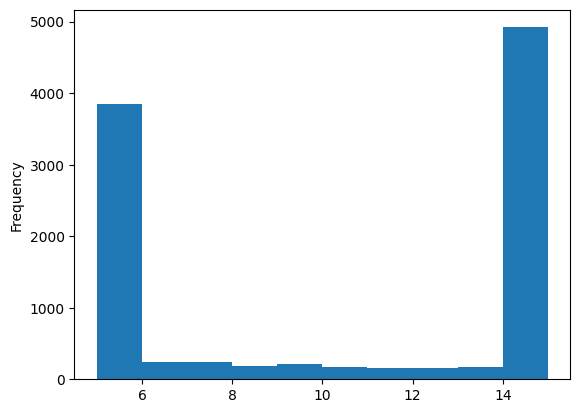

In [111]:
norm_days['norm_days'].plot.hist()

In [115]:
norms = final_df.copy()

In [116]:
norms = norms[['key2', 'run_month', 'month_date', 'Offtake Chain FC PSKU Forecast Vol']]

In [117]:
norms['total_days_in_month'] = norms['month_date'].dt.day

In [118]:
len_before_merge = len(norms)
norms = norms.merge(
    norm_days[['key2', 'norm_days']],
    on=['key2'],
    how='left'
)
assert len_before_merge == len(norms)
del len_before_merge

In [119]:
norms['safety_stock'] = norms['Offtake Chain FC PSKU Forecast Vol'] *  norms['norm_days'] / norms['total_days_in_month']

In [120]:
norms.isna().sum()

key2                                       0
run_month                                  0
month_date                                 0
Offtake Chain FC PSKU Forecast Vol    123394
total_days_in_month                        0
norm_days                             164178
safety_stock                          175030
dtype: int64

In [121]:
norms

,key2,run_month,month_date,Offtake Chain FC PSKU Forecast Vol,total_days_in_month,norm_days,safety_stock
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-11-30,2025-10-31,NaN,31,6.530321,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718299,2025-11-30,2025-10-31,NaN,31,NaN,NaN
2,Blinkit_ahmedabad a2 - feeder warehouse_718308,2025-11-30,2025-10-31,NaN,31,NaN,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718310,2025-11-30,2025-10-31,NaN,31,5.000000,NaN
4,Blinkit_ahmedabad a2 - feeder warehouse_718312,2025-11-30,2025-10-31,NaN,31,5.923442,NaN
...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810673,2025-11-30,2026-04-30,0.0,30,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810674,2025-11-30,2026-04-30,0.0,30,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810685,2025-11-30,2026-04-30,0.0,30,15.000000,0.0
235856,Zepto_pun-dry-mh2-koregaon_810738,2025-11-30,2026-04-30,0.0,30,NaN,NaN


In [122]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    norms.drop(['Offtake Chain FC PSKU Forecast Vol', 'total_days_in_month', 'norm_days'], axis=1).rename(columns={
        'safety_stock': 'norms_soh'
    }),
    on=['key2', 'run_month', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [123]:
norms['month_date'] = norms['month_date'] - MonthEnd(1)

In [124]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    norms.drop(['Offtake Chain FC PSKU Forecast Vol', 'total_days_in_month'], axis=1),
    on=['key2', 'run_month', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [125]:
final_df.sort_values(
    by=['run_month', 'key2', 'month_date'], inplace=True
)

In [126]:
final_df['safety_stock'] = final_df['safety_stock'].fillna(0)

In [127]:
final_df.sort_values(by=['run_month', 'key2', 'month_date'], inplace=True)

In [128]:
norms

,key2,run_month,month_date,Offtake Chain FC PSKU Forecast Vol,total_days_in_month,norm_days,safety_stock
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-11-30,2025-09-30,NaN,31,6.530321,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718299,2025-11-30,2025-09-30,NaN,31,NaN,NaN
2,Blinkit_ahmedabad a2 - feeder warehouse_718308,2025-11-30,2025-09-30,NaN,31,NaN,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718310,2025-11-30,2025-09-30,NaN,31,5.000000,NaN
4,Blinkit_ahmedabad a2 - feeder warehouse_718312,2025-11-30,2025-09-30,NaN,31,5.923442,NaN
...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810673,2025-11-30,2026-03-31,0.0,30,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810674,2025-11-30,2026-03-31,0.0,30,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810685,2025-11-30,2026-03-31,0.0,30,15.000000,0.0
235856,Zepto_pun-dry-mh2-koregaon_810738,2025-11-30,2026-03-31,0.0,30,NaN,NaN


In [129]:
chain_wise_max_soh_dates = soh_df.groupby(
    ['run_month', 'chain'], as_index=False
)['as_on_date'].max()

chain_wise_max_soh_dates

,run_month,chain,as_on_date
0,2025-07-31,Blinkit,2025-07-30
1,2025-07-31,Swiggy,2025-07-30
2,2025-07-31,Zepto,2025-07-30
3,2025-08-31,Blinkit,2025-08-30
4,2025-08-31,Swiggy,2025-08-30
5,2025-08-31,Zepto,2025-08-30
6,2025-09-30,Blinkit,2025-09-30
7,2025-09-30,Swiggy,2025-09-30
8,2025-09-30,Zepto,2025-09-30
9,2025-10-31,Blinkit,2025-10-31


In [130]:
chain_wise_max_soh_dates = (
    chain_wise_max_soh_dates
    .groupby('chain')
    .apply(lambda x: dict(zip(x['run_month'], x['as_on_date'])))
    .to_dict()
)

In [131]:
last_date_soh = pd.DataFrame()

for c in chain_wise_max_soh_dates.keys():
    for rm in chain_wise_max_soh_dates[c].keys():
        last_date_soh = pd.concat([
            last_date_soh,
            soh_df[
                (soh_df['chain'] == c) &
                (soh_df['as_on_date'] == chain_wise_max_soh_dates[c][rm])
            ]
        ])

In [132]:
last_date_soh['as_on_date'] = last_date_soh['as_on_date'] + MonthEnd(0)

In [133]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    last_date_soh[['key2', 'as_on_date', 'current_soh']].rename(
        columns={
            'as_on_date': 'month_date',
            'current_soh': 'Actual Closing SOH'
        }
    ),
    on=['key2', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [134]:
final_df.sort_values(by=['run_month', 'key2', 'month_date'], inplace=True)

In [135]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Contribution,Final Contribution,Offtake Chain FC PSKU,M month,Offtake Chain PSKU Forecast Vol,Offtake Chain FC PSKU Forecast Vol,norms_soh,norm_days,safety_stock,Actual Closing SOH
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,0.129368,0.129368,8.579435,NaN,NaN,NaN,NaN,6.530321,1.645897,0.402
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,0.117817,0.117817,3.767090,M,64.177146,7.561177,1.645897,6.530321,1.757010,0.402
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,0.117817,0.117817,NaN,M+1,70.793361,8.340681,1.757010,6.530321,1.747948,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,0.117817,0.117817,NaN,M+2,70.428202,8.297659,1.747948,6.530321,1.964115,NaN
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,0.117817,0.117817,NaN,M+3,71.479498,8.421520,1.964115,6.530321,1.971552,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,0.058824,NaN,M+1,NaN,NaN,NaN,NaN,0.000000,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,0.058824,NaN,M+2,NaN,NaN,NaN,NaN,0.000000,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,0.058824,NaN,M+3,NaN,NaN,NaN,NaN,0.000000,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,0.058824,NaN,M+4,NaN,NaN,NaN,NaN,0.000000,NaN


In [136]:
final_df['Actual Closing SOH_Lag_1'] = final_df.groupby(
    ['run_month', 'key2']
)['Actual Closing SOH'].shift(1)

In [137]:
final_df['safety_stock'].sum()

205112.98817725183

In [138]:
final_df['Assumed Closing SOH'] = np.where(
    final_df['M month'] == 'M',  
    final_df['Actual Closing SOH_Lag_1'].fillna(0) + final_df['sec_apo_plan_vol_rum'].fillna(0) \
    - final_df['Offtake Chain FC PSKU Forecast Vol'].fillna(0),
    final_df['safety_stock']
)

In [139]:
final_df['Assumed Closing SOH'] = final_df['Assumed Closing SOH'].clip(lower=0.0)

In [140]:
final_df['Assumed Closing SOH_Lag_1'] = final_df.groupby(
    ['run_month', 'key2']
)['Assumed Closing SOH'].shift(1)

In [141]:
final_df = final_df[
    ~final_df['material_group_code'].isin(['NC FREE', 'HC FREE'])
]

In [142]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,M month,Offtake Chain PSKU Forecast Vol,Offtake Chain FC PSKU Forecast Vol,norms_soh,norm_days,safety_stock,Actual Closing SOH,Actual Closing SOH_Lag_1,Assumed Closing SOH,Assumed Closing SOH_Lag_1
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,NaN,NaN,NaN,NaN,6.530321,1.645897,0.402,NaN,1.645897,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,M,64.177146,7.561177,1.645897,6.530321,1.757010,0.402,0.402,0.604723,1.645897
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,M+1,70.793361,8.340681,1.757010,6.530321,1.747948,NaN,0.402,1.747948,0.604723
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,M+2,70.428202,8.297659,1.747948,6.530321,1.964115,NaN,NaN,1.964115,1.747948
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,M+3,71.479498,8.421520,1.964115,6.530321,1.971552,NaN,NaN,1.971552,1.964115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,M+1,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,M+2,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,M+3,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,M+4,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000


In [143]:
soh_df['as_on_date'].max()

Timestamp('2025-11-19 00:00:00')

### Add P3M, LY

In [144]:
actuals_df = plan_actuals_df.copy()
actuals_df['month_date'] = actuals_df['month_date'] + MonthEnd(0)

In [145]:
actuals_df = actuals_df.groupby(
    ['key2', 'month_date'], as_index=False
)[['pri_actuals_vol_rum', 'sec_actuals_vol_rum']].sum()

In [146]:
actuals_df.duplicated(subset=['key2', 'month_date']).sum()

0

In [147]:
actuals_df['month_date'].min()

Timestamp('2024-01-31 00:00:00')

In [148]:
actuals_df.sort_values(by=['key2', 'month_date'], inplace=True)

In [149]:
actuals_df['Primary P3M redundant'] = actuals_df.groupby(
['key2'], as_index = False, group_keys = False)['pri_actuals_vol_rum'].shift(1)\
                            .rolling(window=3, min_periods=3).mean()

In [150]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    actuals_df.rename(columns={
        'pri_actuals_vol_rum': 'Primary Actuals Vol',
        'sec_actuals_vol_rum': 'Sec Actuals Vol'
    }),
    on=['key2', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [151]:
final_df.isna().sum()

key2                                           0
chain                                          0
facility_name                               6104
parent_material_code                           0
material_group_code                            0
run_month                                      0
month_date                                     0
pri_actuals_vol_rum                         1226
sec_apo_plan_vol_rum                        1226
Primary P3M                                 1226
key                                            0
Offtake Chain PSKU                        202827
Primary Actuals Chain PSKU P3M Sum Vol         0
Group Size                                     0
Fallback Contribution                          0
Contribution                              129592
Final Contribution                             0
Offtake Chain FC PSKU                     202827
M month                                    33694
Offtake Chain PSKU Forecast Vol           123394
Offtake Chain FC PSK

In [152]:
plan_actuals_df

,month_date,key2,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
0,2024-09-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,1.728,0.000000,0.0,1.728,NaN
1,2024-10-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,8.664,0.607765,0.0,8.664,1.728
2,2024-11-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2.832,0.260008,0.0,2.832,5.196
3,2024-12-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,7.320,0.550052,0.0,7.320,4.408
4,2025-01-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,5.880,0.675054,0.0,5.880,6.272
...,...,...,...,...,...,...,...,...,...,...,...
633877,2025-12-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633878,2026-01-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633879,2026-02-28,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633880,2026-03-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000


In [153]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,norms_soh,norm_days,safety_stock,Actual Closing SOH,Actual Closing SOH_Lag_1,Assumed Closing SOH,Assumed Closing SOH_Lag_1,Primary Actuals Vol,Sec Actuals Vol,Primary P3M redundant
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,NaN,6.530321,1.645897,0.402,NaN,1.645897,NaN,5.784,5.784,7.952
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,1.645897,6.530321,1.757010,0.402,0.402,0.604723,1.645897,3.864,0.000,6.840
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,1.757010,6.530321,1.747948,NaN,0.402,1.747948,0.604723,0.000,0.000,6.664
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,1.747948,6.530321,1.964115,NaN,NaN,1.964115,1.747948,0.000,0.000,3.216
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,1.964115,6.530321,1.971552,NaN,NaN,1.971552,1.964115,0.000,0.000,1.288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000,0.000,0.000
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000,0.000,0.000
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000,0.000,0.000
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000,0.000,0.000


In [154]:
ly_actuals_df = actuals_df.copy()

In [155]:
ly_actuals_df['month_date'] = ly_actuals_df['month_date'] + MonthEnd(12)

In [156]:
ly_actuals_df.rename(columns={
        'pri_actuals_vol_rum': 'LY Primary Actuals Vol',
        'sec_actuals_vol_rum': 'LY Sec Actuals Vol',
        'Primary P3M redundant': 'LY Primary P3M'
    })

,key2,month_date,LY Primary Actuals Vol,LY Sec Actuals Vol,LY Primary P3M
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-09-30,1.728,1.728,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-10-31,8.664,8.664,NaN
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-11-30,2.832,2.832,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,2025-12-31,7.320,7.320,4.408
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,2026-01-31,5.880,5.880,6.272
...,...,...,...,...,...
633877,Zepto_pun-dry-mh2-koregaon_810805,2026-12-31,0.000,0.000,0.000
633878,Zepto_pun-dry-mh2-koregaon_810805,2027-01-31,0.000,0.000,0.000
633879,Zepto_pun-dry-mh2-koregaon_810805,2027-02-28,0.000,0.000,0.000
633880,Zepto_pun-dry-mh2-koregaon_810805,2027-03-31,0.000,0.000,0.000


In [157]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    ly_actuals_df.rename(columns={
        'pri_actuals_vol_rum': 'LY Primary Actuals Vol',
        'sec_actuals_vol_rum': 'LY Sec Actuals Vol',
        'Primary P3M redundant': 'LY Primary P3M'
    }),
    on=['key2', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [158]:
final_df[final_df['Contribution'].isna()]

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Actual Closing SOH,Actual Closing SOH_Lag_1,Assumed Closing SOH,Assumed Closing SOH_Lag_1,Primary Actuals Vol,Sec Actuals Vol,Primary P3M redundant,LY Primary Actuals Vol,LY Sec Actuals Vol,LY Primary P3M
7,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-10-31,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
8,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-11-30,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
9,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-12-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
10,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2026-01-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2026-02-28,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [159]:
final_df['Contribution'].isna()

0         False
1         False
2         False
3         False
4         False
          ...  
235853     True
235854     True
235855     True
235856     True
235857     True
Name: Contribution, Length: 235858, dtype: bool

In [160]:
final_df[final_df['Contribution'].isna()]

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Actual Closing SOH,Actual Closing SOH_Lag_1,Assumed Closing SOH,Assumed Closing SOH_Lag_1,Primary Actuals Vol,Sec Actuals Vol,Primary P3M redundant,LY Primary Actuals Vol,LY Sec Actuals Vol,LY Primary P3M
7,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-10-31,0.0,0.0,0.0,...,NaN,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
8,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-11-30,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
9,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2025-12-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
10,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2026-01-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-11-30,2026-02-28,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [165]:
offtakes_monthly_df['month_date'].max()

Timestamp('2025-09-30 00:00:00')

In [110]:
final_offtakes_historical_df = offtakes_monthly_df.copy()

In [168]:
final_offtakes_historical_df

,chain,parent_material_code,material_group_code,month_date,offtake_vol_rum
0,Blinkit,718288,SAFF GOLD,2023-01-31,22.584
1,Blinkit,718288,SAFF GOLD,2023-02-28,17.568
2,Blinkit,718288,SAFF GOLD,2023-03-31,25.332
3,Blinkit,718288,SAFF GOLD,2023-04-30,21.888
4,Blinkit,718288,SAFF GOLD,2023-05-31,15.860
...,...,...,...,...,...
12916,Zepto,810522,SAF_CDPRS,2025-10-31,0.103
12917,Zepto,810673,PA_ESS_HO,2025-10-31,0.168
12918,Zepto,810674,PA_ESS_HO,2025-10-31,0.168
12919,Zepto,810685,SAF-MUSLI,2025-10-31,0.034


In [169]:
final_offtakes_historical_df.duplicated(subset=['chain', 'parent_material_code', 'month_date']).sum()

0

In [170]:
final_offtakes_historical_df['key'] = final_offtakes_historical_df[['chain', 'parent_material_code']].astype(str).agg(
    '_'.join, axis=1
)

In [171]:

final_offtakes_historical_df.sort_values(
    by=['key', 'month_date'], inplace=True
)

In [172]:
final_offtakes_historical_df['P3M'] = final_offtakes_historical_df.groupby(
    ['key'], as_index = False, group_keys = False)['offtake_vol_rum'].shift(1)\
                                .rolling(window=3, min_periods=3).mean()

In [173]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    final_offtakes_historical_df[['key', 'month_date', 'offtake_vol_rum', 'P3M']].rename(
        columns={'P3M': 'Offtake P3M', 'offtake_vol_rum': 'Offtake Actuals Vol'}
    ),
    on=['key', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [174]:
ly_final_offtakes_historical_df = final_offtakes_historical_df.copy()

In [175]:
ly_final_offtakes_historical_df['month_date'].min()

Timestamp('2023-01-31 00:00:00')

In [176]:
ly_final_offtakes_historical_df['month_date'] = ly_final_offtakes_historical_df['month_date'] + MonthEnd(12)
ly_final_offtakes_historical_df.head()

,chain,parent_material_code,material_group_code,month_date,offtake_vol_rum,key,P3M
0,Blinkit,718288,SAFF GOLD,2024-01-31,22.584,Blinkit_718288,NaN
1,Blinkit,718288,SAFF GOLD,2024-02-29,17.568,Blinkit_718288,NaN
2,Blinkit,718288,SAFF GOLD,2024-03-31,25.332,Blinkit_718288,NaN
3,Blinkit,718288,SAFF GOLD,2024-04-30,21.888,Blinkit_718288,21.828
4,Blinkit,718288,SAFF GOLD,2024-05-31,15.860,Blinkit_718288,21.596


In [177]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    ly_final_offtakes_historical_df[['key', 'month_date', 'offtake_vol_rum', 'P3M']].rename(
        columns={'P3M': 'LY Offtake P3M', 'offtake_vol_rum': 'LY Offtake Actuals Vol'}
    ),
    on=['key', 'month_date'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [178]:
final_df.sort_values(by=['run_month', 'key2', 'month_date'], inplace=True)

In [179]:
for col in ['Primary P3M', 'LY Primary P3M', 'Offtake P3M', 'LY Offtake P3M', 'Primary P3M redundant']:
    # if not 'LY' in col:  'LY P6M',
    final_df.loc[final_df['month_date'] > final_df['run_month'], [col]] = np.nan
    final_df[col] = final_df.groupby(['run_month', 'key2'], as_index = True, group_keys = False)[col].apply(
        lambda x: x.ffill()
    )

In [180]:
final_offtakes_historical_df

,chain,parent_material_code,material_group_code,month_date,offtake_vol_rum,key,P3M
0,Blinkit,718288,SAFF GOLD,2023-01-31,22.584,Blinkit_718288,NaN
1,Blinkit,718288,SAFF GOLD,2023-02-28,17.568,Blinkit_718288,NaN
2,Blinkit,718288,SAFF GOLD,2023-03-31,25.332,Blinkit_718288,NaN
3,Blinkit,718288,SAFF GOLD,2023-04-30,21.888,Blinkit_718288,21.828000
4,Blinkit,718288,SAFF GOLD,2023-05-31,15.860,Blinkit_718288,21.596000
...,...,...,...,...,...,...,...
12323,Zepto,810685,SAF-MUSLI,2025-09-30,0.012,Zepto_810685,0.008533
12919,Zepto,810685,SAF-MUSLI,2025-10-31,0.034,Zepto_810685,0.011867
12324,Zepto,810738,PABABY_GM,2025-08-31,0.724,Zepto_810738,NaN
12325,Zepto,810738,PABABY_GM,2025-09-30,4.344,Zepto_810738,NaN


In [181]:
final_offtakes_historical_df.sort_values(by=['key', 'month_date'], inplace=True)

In [182]:
# final_offtakes_historical_df['OT_Lag_1'] = final_offtakes_historical_df.groupby(
#     ['material_group_code', 'key']
# )['offtake_vol_rum'].shift(1)

# final_offtakes_historical_df['OT_Lag_2'] = final_offtakes_historical_df.groupby(
#     ['material_group_code', 'key']
# )['offtake_vol_rum'].shift(2)

# final_offtakes_historical_df['OT_Lag_3'] = final_offtakes_historical_df.groupby(
#     ['material_group_code', 'key']
# )['offtake_vol_rum'].shift(3)

In [183]:
# del final_df['OT_Lag_1'], final_df['OT_Lag_2'], final_df['OT_Lag_3']

In [184]:
# len_before_merge = len(final_df)
# final_df = final_df.merge(
#     final_offtakes_historical_df[['key', 'month_date', 'OT_Lag_1', 'OT_Lag_2', 'OT_Lag_3']].rename(
#         columns={'month_date': 'run_month'}
#     ),
#     on=['key', 'run_month'],
#     how='left'
# )
# assert len_before_merge == len(final_df)
# del len_before_merge

In [185]:
lags_df = plan_actuals_df.copy()

In [186]:
lags_df.sort_values(by=['key2', 'month_date'], inplace=True)

In [187]:
lags_df

,month_date,key2,chain,facility_name,parent_material_code,material_group_code,pri_actuals_vol_rum,pri_apo_plan_vol_rum,sec_apo_plan_vol_rum,sec_actuals_vol_rum,Primary P3M
0,2024-09-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,1.728,0.000000,0.0,1.728,NaN
1,2024-10-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,8.664,0.607765,0.0,8.664,1.728
2,2024-11-30,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2.832,0.260008,0.0,2.832,5.196
3,2024-12-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,7.320,0.550052,0.0,7.320,4.408
4,2025-01-31,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,5.880,0.675054,0.0,5.880,6.272
...,...,...,...,...,...,...,...,...,...,...,...
633877,2025-12-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633878,2026-01-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633879,2026-02-28,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000
633880,2026-03-31,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,0.000,0.000000,0.0,0.000,0.000


In [188]:
lags_df['Primary_Lag_2'] = lags_df.groupby(
    ['material_group_code', 'key2']
)['pri_actuals_vol_rum'].shift(1)

lags_df['Primary_Lag_3'] = lags_df.groupby(
    ['material_group_code', 'key2']
)['pri_actuals_vol_rum'].shift(2)

In [189]:
lags_df['month_date'] = lags_df['month_date'] + MonthEnd(1)

In [190]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    lags_df[['key2', 'month_date', 'pri_actuals_vol_rum', 'Primary_Lag_2', 'Primary_Lag_3']].rename(columns={
        'month_date': 'run_month',
        'pri_actuals_vol_rum': 'Primary_Lag_1'
    }),
    on=['key2', 'run_month'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [191]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,LY Primary Actuals Vol,LY Sec Actuals Vol,LY Primary P3M,Offtake Actuals Vol,Offtake P3M,LY Offtake Actuals Vol,LY Offtake P3M,Primary_Lag_1,Primary_Lag_2,Primary_Lag_3
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,8.664,8.664,NaN,66.318,56.036,41.556,27.651667,5.784,10.344,4.392
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,2.832,2.832,NaN,NaN,56.036,35.844,32.292000,5.784,10.344,4.392
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,7.320,7.320,NaN,NaN,56.036,44.304,32.292000,5.784,10.344,4.392
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,5.880,5.880,NaN,NaN,56.036,44.688,32.292000,5.784,10.344,4.392
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,8.784,8.784,NaN,NaN,56.036,44.646,32.292000,5.784,10.344,4.392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000


In [192]:
lags_final_offtakes_historical_df = final_offtakes_historical_df.copy()

lags_final_offtakes_historical_df.sort_values(by=['key', 'month_date'], inplace=True)
lags_final_offtakes_historical_df['OT_Lag_2'] = lags_final_offtakes_historical_df.groupby(
    ['material_group_code', 'key']
)['offtake_vol_rum'].shift(1)

lags_final_offtakes_historical_df['OT_Lag_3'] = lags_final_offtakes_historical_df.groupby(
    ['material_group_code', 'key']
)['offtake_vol_rum'].shift(2)

In [193]:
# del final_df['OT_Lag_1'], final_df['OT_Lag_2'], final_df['OT_Lag_3']

In [194]:
lags_final_offtakes_historical_df['month_date'] = lags_final_offtakes_historical_df['month_date'] + MonthEnd(1)

In [195]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    lags_final_offtakes_historical_df[['key', 'month_date', 'offtake_vol_rum', 'OT_Lag_2', 'OT_Lag_3']].rename(columns={
        'month_date': 'run_month',
        'offtake_vol_rum': 'OT_Lag_1'
    }),
    on=['key', 'run_month'],
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [196]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Offtake Actuals Vol,Offtake P3M,LY Offtake Actuals Vol,LY Offtake P3M,Primary_Lag_1,Primary_Lag_2,Primary_Lag_3,OT_Lag_1,OT_Lag_2,OT_Lag_3
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,66.318,56.036,41.556,27.651667,5.784,10.344,4.392,66.318,52.722,58.344
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,NaN,56.036,35.844,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,NaN,56.036,44.304,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,NaN,56.036,44.688,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,NaN,56.036,44.646,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN


In [197]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Offtake Actuals Vol,Offtake P3M,LY Offtake Actuals Vol,LY Offtake P3M,Primary_Lag_1,Primary_Lag_2,Primary_Lag_3,OT_Lag_1,OT_Lag_2,OT_Lag_3
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-10-31,5.784,6.2572,7.952,...,66.318,56.036,41.556,27.651667,5.784,10.344,4.392,66.318,52.722,58.344
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-11-30,3.864,7.7639,6.840,...,NaN,56.036,35.844,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2025-12-31,0.000,0.0000,6.840,...,NaN,56.036,44.304,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
3,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-01-31,0.000,0.0000,6.840,...,NaN,56.036,44.688,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
4,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-11-30,2026-02-28,0.000,0.0000,6.840,...,NaN,56.036,44.646,32.292000,5.784,10.344,4.392,66.318,52.722,58.344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235853,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2025-12-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235854,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-01-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235855,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-02-28,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN
235856,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-11-30,2026-03-31,0.000,0.0000,0.000,...,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN,NaN


In [198]:
final_offtakes_historical_df

,chain,parent_material_code,material_group_code,month_date,offtake_vol_rum,key,P3M
0,Blinkit,718288,SAFF GOLD,2023-01-31,22.584,Blinkit_718288,NaN
1,Blinkit,718288,SAFF GOLD,2023-02-28,17.568,Blinkit_718288,NaN
2,Blinkit,718288,SAFF GOLD,2023-03-31,25.332,Blinkit_718288,NaN
3,Blinkit,718288,SAFF GOLD,2023-04-30,21.888,Blinkit_718288,21.828000
4,Blinkit,718288,SAFF GOLD,2023-05-31,15.860,Blinkit_718288,21.596000
...,...,...,...,...,...,...,...
12323,Zepto,810685,SAF-MUSLI,2025-09-30,0.012,Zepto_810685,0.008533
12919,Zepto,810685,SAF-MUSLI,2025-10-31,0.034,Zepto_810685,0.011867
12324,Zepto,810738,PABABY_GM,2025-08-31,0.724,Zepto_810738,NaN
12325,Zepto,810738,PABABY_GM,2025-09-30,4.344,Zepto_810738,NaN


### Format

In [111]:
brand_md_df = pd.read_excel(r"C:\Users\aniket.patel\Downloads\Brand_metadata.xlsx")
brand_md_df.head()

,brand_code,portfolio
0,ADV-AHO-R,Hair Oils
1,ADV-COL-R,Hair Oils
2,ADV-COL-S,Hair Oils
3,BD_BDOL_M,Male Grooming
4,BD_HRWX_M,Male Grooming


In [112]:
def read_qtr_ind_rate_table():
    query = """select * from DWH_SAP_INDEX_TURNOVER_MONTHWISE 
                where latest_rate_flag=1 and company_code='MIL'"""
    qtr_ind_rate_data = pd.read_sql(con=prod_conn, sql=query)
    qtr_ind_rate_data.columns = qtr_ind_rate_data.columns.str.lower()
    qtr_ind_rate =  qtr_ind_rate_data[['date', 'brand_code', 'turnover']]
    qtr_ind_rate = qtr_ind_rate.rename(columns= {'date':'month_date', 'turnover':'qtr_ind_rate'})
    
    return qtr_ind_rate

qtr_ind_rate_df = read_qtr_ind_rate_table()
qtr_ind_rate_df.head()

,month_date,brand_code,qtr_ind_rate
0,2026-03-31,PABABY_SP,415.245000
1,2026-03-31,P_GOHR_SR,7470.000000
2,2026-03-31,PA_JAS_GD,298.847906
3,2026-03-31,PA_NOR_HO,188992.000000
4,2026-03-31,PA_GD_PLS,309765.000000


In [ ]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    qtr_ind_rate_df.drop('month_date', axis=1).rename(
        columns={'brand_code': 'material_group_code'}
    ),
    on=['material_group_code'], 
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [ ]:
len_before_merge = len(final_df)
final_df = final_df.merge(
    brand_md_df.rename(
        columns={'brand_code': 'material_group_code'}
    ),
    on=['material_group_code'], 
    how='left'
)
assert len_before_merge == len(final_df)
del len_before_merge

In [ ]:
final_df.columns

In [ ]:
final_df = final_df.rename(columns={
    'key2': 'Key2',
    'key': 'Key',
    'chain': 'Chain',
    'facility_name': 'FC',
    'parent_material_code': 'PSKU',
    'material_group_code': 'Brand',
    'run_month': 'Run Month',
    'month_date': 'Month Date',
    'pri_actuals_vol_rum': 'Primary Till Date Actuals Vol',
    'sec_apo_plan_vol_rum': 'Secondary Plan Vol',
    'Primary P3M': 'Primary P3M Vol',
    'city': 'City', 
    'Offtake Chain City PSKU': 'Offtake Chain City PSKU Vol',
    'Offtake Chain FC PSKU': 'Offtake Chain FC PSKU Vol',
    'norms_soh': 'Norms SOH',
    'norm_days': 'Norm Days',
    'safety_stock': 'Safety Stock Vol',
    'Actual Closing SOH': 'Actual Closing SOH Vol',
    'Actual Closing SOH_Lag_1': 'Actual Closing SOH Lag 1 Vol',
    'Assumed Closing SOH': 'Assumed Closing SOH Vol',
    'Assumed Closing SOH_Lag_1': 'Assumed Closing SOH Lag 1 Vol',
    'Primary P3M redundant': 'Primary P3M redundant Vol',
    'LY Primary P3M': 'LY Primary P3M Vol',
    'Offtake P3M': 'Offtake P3M Vol',
    'LY Offtake P3M': 'LY Offtake P3M Vol',
    'Primary_Lag_1': 'Primary Actuals Lag 1 Vol',
    'Primary_Lag_2': 'Primary Actuals Lag 2 Vol',
    'Primary_Lag_3': 'Primary Actuals Lag 3 Vol',
    'OT_Lag_1': 'Offtake Actuals Lag 1 Vol',
    'OT_Lag_2': 'Offtake Actuals Lag 2 Vol',
    'OT_Lag_3': 'Offtake Actuals Lag 3 Vol',
    'qtr_ind_rate': 'Index Rate',
    'portfolio': 'Portfolio'
})

In [199]:
final_df.to_excel('Offtakes_to_Primary_live_run_Nov25_v5.xlsx', index=False)

In [156]:
final_df['Actual Closing SOH'].isna().sum()

195114

In [157]:
final_df

,key2,chain,facility_name,parent_material_code,material_group_code,run_month,month_date,pri_actuals_vol_rum,sec_apo_plan_vol_rum,Primary P3M,...,Offtake Chain PSKU,Primary Actuals Chain PSKU P3M Sum Vol,Contribution,Offtake Chain FC PSKU,M month,norms_soh,norm_days,safety_stock,Actual Closing SOH,Actual Closing SOH_Lag_1
0,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-08-31,2025-08-31,4.392,6.0346,7.912,...,58.344,57.460,0.137696,8.033723,M,NaN,NaN,0.0,NaN,NaN
1,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-08-31,2025-09-30,10.344,3.8295,6.560,...,52.722,108.796,0.060296,3.178943,M+1,NaN,NaN,0.0,NaN,NaN
2,Blinkit_ahmedabad a2 - feeder warehouse_718288,Blinkit,ahmedabad a2 - feeder warehouse,718288,SAFF GOLD,2025-08-31,2025-10-31,5.784,6.2572,7.952,...,66.318,122.000,0.065180,4.322629,M+2,NaN,NaN,0.0,NaN,NaN
3,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-08-31,2025-08-31,0.000,0.0033,0.000,...,NaN,0.000,NaN,NaN,M,NaN,NaN,0.0,NaN,NaN
4,Blinkit_ahmedabad a2 - feeder warehouse_718299,Blinkit,ahmedabad a2 - feeder warehouse,718299,PCNO(R),2025-08-31,2025-09-30,0.000,0.0187,0.000,...,NaN,0.000,NaN,NaN,M+1,NaN,NaN,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195109,Zepto_pun-dry-mh2-koregaon_810738,Zepto,pun-dry-mh2-koregaon,810738,PABABY_GM,2025-09-30,2025-10-31,0.000,0.0000,0.000,...,39.820,63.712,0.000000,0.000000,M+1,NaN,NaN,0.0,NaN,NaN
195110,Zepto_pun-dry-mh2-koregaon_810738,Zepto,pun-dry-mh2-koregaon,810738,PABABY_GM,2025-09-30,2025-11-30,NaN,NaN,NaN,...,15.928,0.000,NaN,NaN,M+2,NaN,NaN,0.0,NaN,NaN
195111,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-09-30,2025-09-30,0.000,0.0000,NaN,...,NaN,0.000,NaN,NaN,M,NaN,NaN,0.0,NaN,NaN
195112,Zepto_pun-dry-mh2-koregaon_810805,Zepto,pun-dry-mh2-koregaon,810805,PABABY_GM,2025-09-30,2025-10-31,0.000,25.7220,0.000,...,NaN,0.000,NaN,NaN,M+1,NaN,NaN,0.0,NaN,NaN
